In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats


In [2]:
df=pd.read_csv("titanic.csv")

In [3]:
df

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Sex                      887 non-null    object 
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


In [5]:
df.describe()

,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887.000000,887.000000,887.000000,887.00000
mean,0.385569,2.305524,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.13750
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.32920


In [6]:
df.isnull().sum()

Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64

In [7]:
df.shape

(887, 8)

In [8]:
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare'],
      dtype='object')

In [9]:
df["Survived"].unique()

array([0, 1], dtype=int64)

In [10]:
df["Sex"].unique()

array(['male', 'female'], dtype=object)

In [11]:
df["Siblings/Spouses Aboard"].unique()

array([1, 0, 3, 4, 2, 5, 8], dtype=int64)

In [12]:
df["Parents/Children Aboard"].unique()

array([0, 1, 2, 5, 3, 4, 6], dtype=int64)

In [13]:
df["Survived"].value_counts()

Survived
0    545
1    342
Name: count, dtype: int64

In [14]:
df[["Survived","Sex"]].value_counts()


Survived  Sex   
0         male      464
1         female    233
          male      109
0         female     81
Name: count, dtype: int64

In [15]:
df.duplicated().sum()

0

In [16]:
df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


# now we do exploratory data analysis

<Axes: ylabel='Age'>

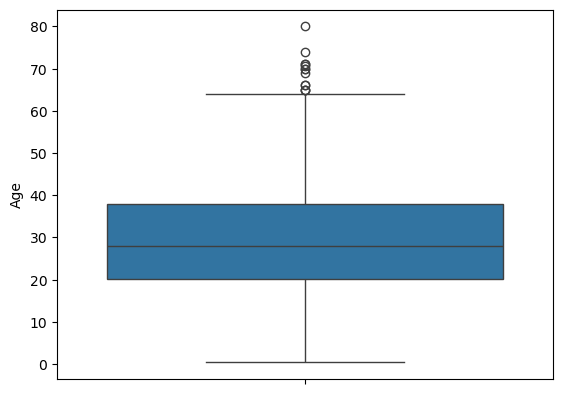

In [17]:
sns.boxplot(df["Age"])

In [18]:
df["Age"].kurtosis()

0.2925590867837582

In [19]:
df["Age"].skew()

0.44718857190799916

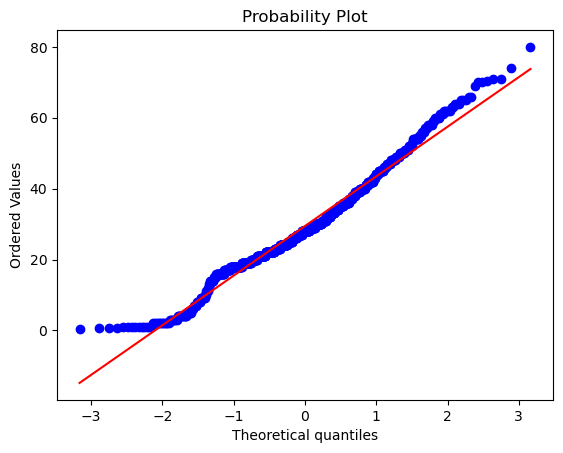

In [20]:
stats.probplot(df["Age"],dist="norm",plot=plt)            
plt.show()

In [21]:
#it is not following normal distribution but is so closed to the normal distribution

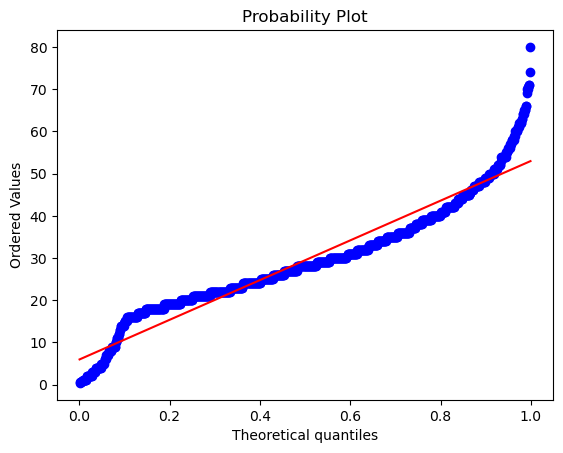

In [22]:
stats.probplot(df["Age"],dist="uniform",plot=plt)            
plt.show()

In [23]:
# this one also not following the normal distribution 

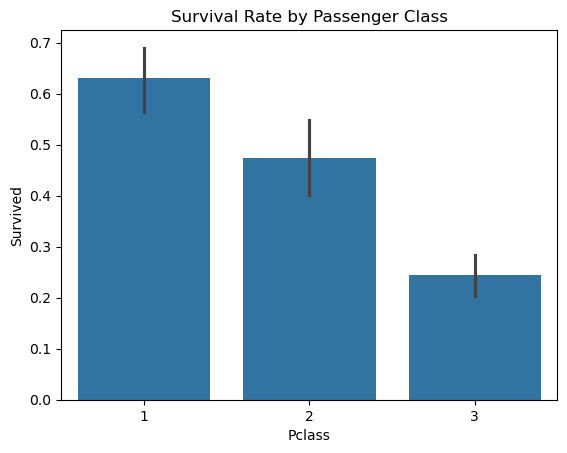

In [24]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

In [25]:
df["Survived"].kurtosis()

-1.7821833417237254

In [26]:
df["Survived"].skew()

0.4709991614295122

these was clearly show the 1st class  people most survived and 3rd class people less survived 

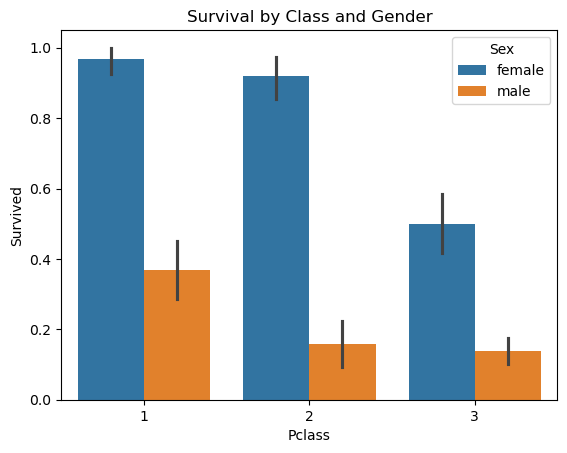

In [27]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.title("Survival by Class and Gender")
plt.show()

these 

In [28]:
df["Pclass"].kurtosis()

-1.2886380105491657

In [29]:
df["Pclass"].skew()

-0.6234088481784408

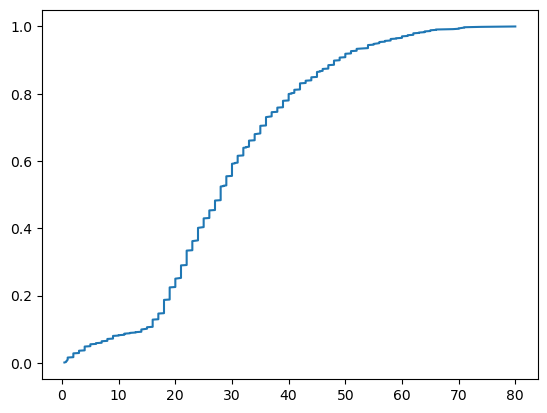

In [30]:
#CDF :-
lst_sort=np.sort(df["Age"])
cf=np.arange(1,len(lst_sort)+1)/len(lst_sort)
plt.plot(lst_sort,cf)
plt.show() # from this CDF i can conclude that the ages are evenly spread, with age group dominating the data.

In [31]:
def detect_outliers_iqr(data):
    outliers = {}
    for col in data.select_dtypes(include=np.number).columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers[col] = data[(data[col] < lower) | (data[col] > upper)][col]
    return outliers
outliers = detect_outliers_iqr(df)
outliers

{'Survived': Series([], Name: Survived, dtype: int64),
 'Pclass': Series([], Name: Pclass, dtype: int64),
 'Age': 33     66.0
 53     65.0
 95     71.0
 115    70.5
 278    65.0
 453    65.0
 490    71.0
 508    66.0
 535    69.0
 627    80.0
 669    70.0
 741    70.0
 847    74.0
 Name: Age, dtype: float64,
 'Siblings/Spouses Aboard': 7      3
 16     4
 24     3
 27     3
 49     4
 58     5
 62     3
 67     4
 70     5
 84     3
 87     3
 118    4
 158    8
 163    4
 170    4
 175    3
 179    8
 181    4
 200    8
 228    3
 232    4
 259    4
 264    4
 276    4
 322    8
 339    3
 372    3
 384    5
 407    3
 477    5
 482    3
 538    4
 539    4
 631    3
 639    3
 680    5
 683    4
 722    3
 783    4
 788    8
 809    4
 815    3
 820    4
 842    8
 846    4
 859    8
 Name: Siblings/Spouses Aboard, dtype: int64,
 'Parents/Children Aboard': 7      1
 8      2
 10     1
 13     5
 16     1
       ..
 867    1
 875    1
 876    1
 881    5
 884    2
 Name: Parents/Child

In [32]:
z_scores = np.abs(stats.zscore(df["Survived"]))  # remove axis=1
outliers_z = z_scores > 3
outliers_z.value_counts()

Survived
False    887
Name: count, dtype: int64

In [33]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Sex                      887 non-null    object 
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


In [35]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [36]:
df

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,1,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,0,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,0,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,0,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,1,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,1,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,0,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,0,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,1,26.0,0,0,30.0000


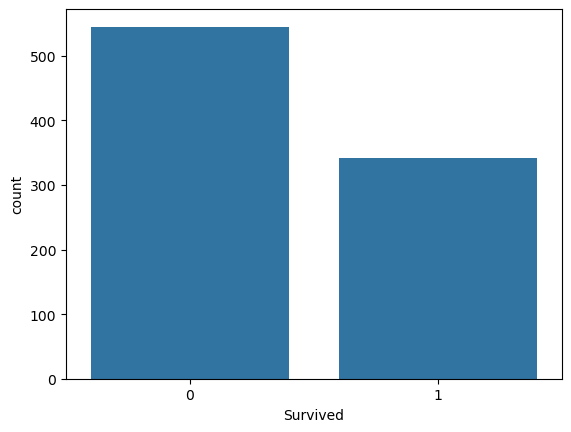

In [37]:
sns.countplot(x='Survived', data=df)
plt.show()

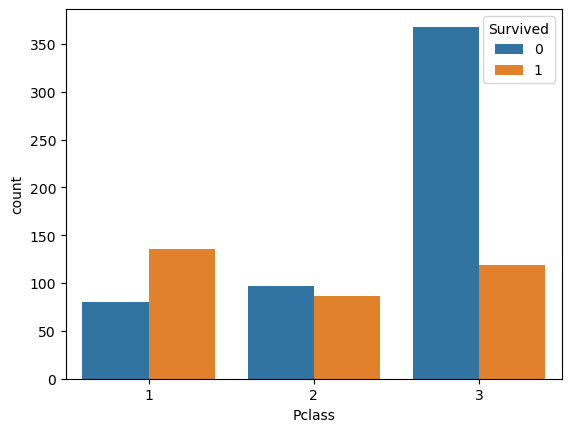

In [38]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

In [39]:
df.drop('Name', axis=1, inplace=True)

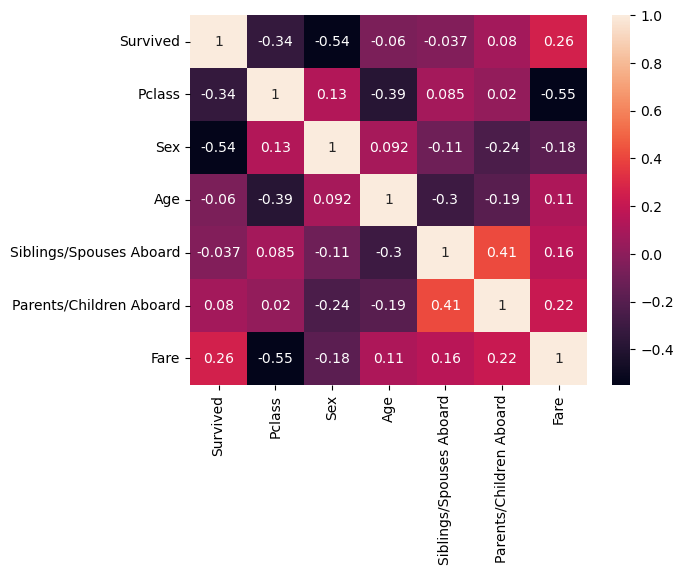

In [40]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [41]:
from sklearn.model_selection import train_test_split
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:

X_train

,Pclass,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
730,2,1,23.0,0,0,13.0000
390,3,1,28.0,2,0,7.9250
118,3,0,2.0,4,2,31.2750
440,2,0,28.0,0,0,13.0000
309,1,0,18.0,2,2,262.3750
...,...,...,...,...,...,...
106,3,1,29.0,0,0,7.7750
270,2,0,41.0,0,1,19.5000
860,2,1,24.0,0,0,13.0000
435,1,1,64.0,1,4,263.0000


In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [44]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7528089887640449


In [45]:
from sklearn.metrics import confusion_matrix

In [46]:
y_pred = model.predict(X_test)

In [47]:
y_pred 

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0], dtype=int64)

In [48]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[97 14]
 [30 37]]


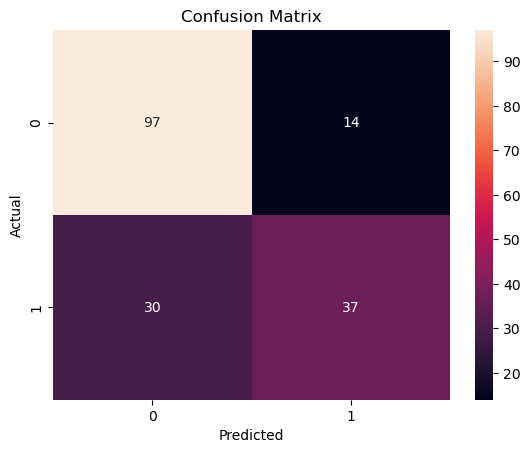

In [49]:
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [50]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.87      0.82       111
           1       0.73      0.55      0.63        67

    accuracy                           0.75       178
   macro avg       0.74      0.71      0.72       178
weighted avg       0.75      0.75      0.74       178



In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [52]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, rf_pred))

RF Accuracy: 0.7808988764044944


In [53]:
importance = rf.feature_importances_
features = X.columns
for i, j in zip(features, importance):
    print(i, j)

Pclass 0.08820686542815322
Sex 0.29396477159205514
Age 0.25231283331506554
Siblings/Spouses Aboard 0.05016404085089874
Parents/Children Aboard 0.035255965743609084
Fare 0.2800955230702183


In [54]:
from sklearn.metrics import roc_curve

In [55]:
import pickle

pickle.dump(model, open('titanic_model.pkl', 'wb'))

In [57]:
df.to_csv("output.csv", index=False)
